Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


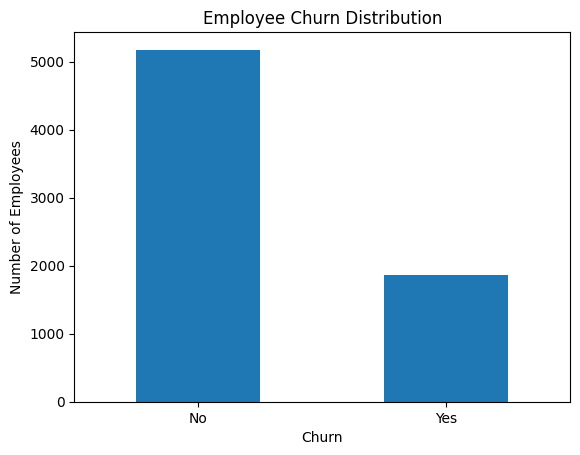

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


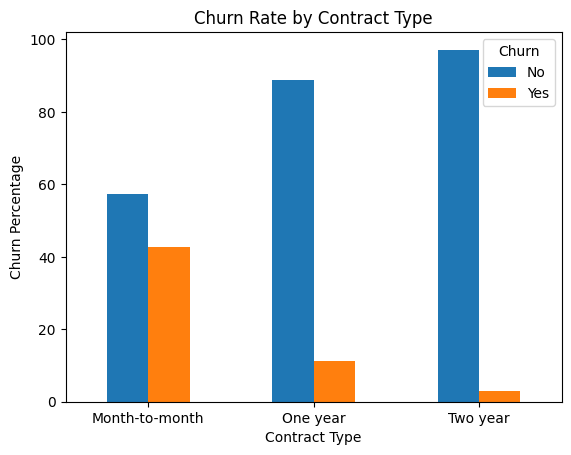

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


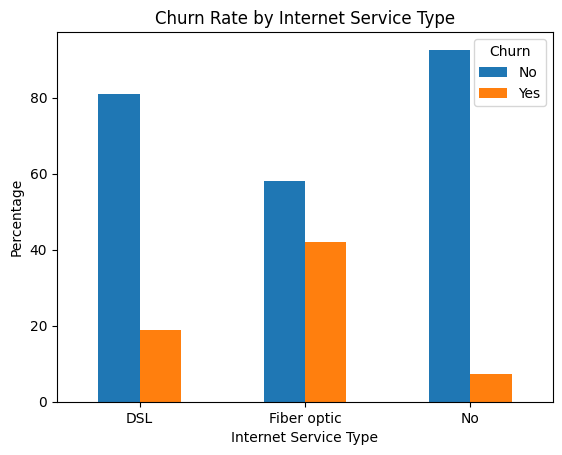

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


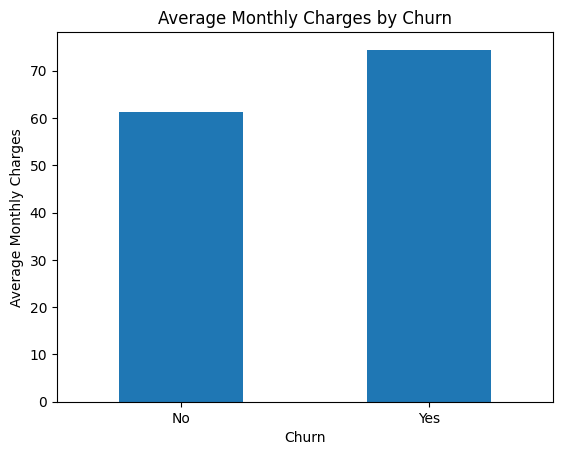

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


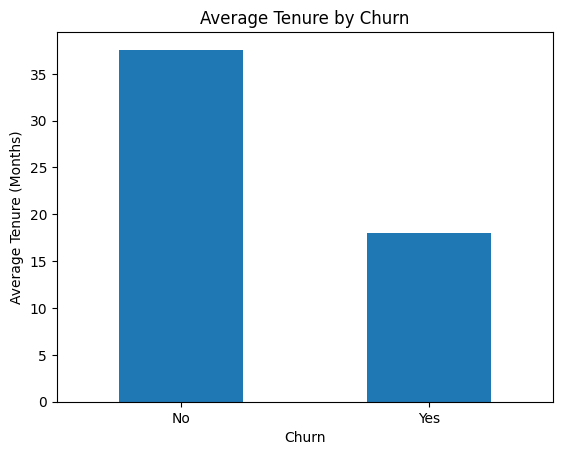

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


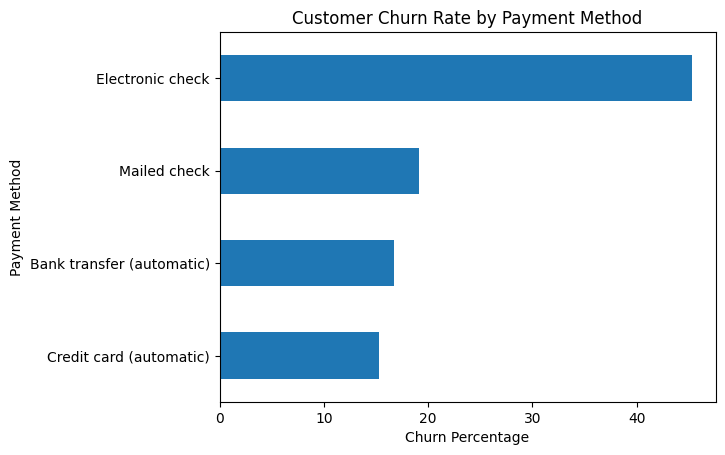

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


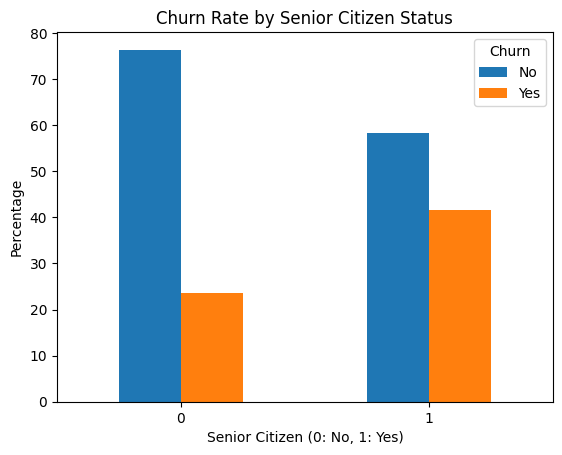

                SeniorCitizen    tenure  MonthlyCharges
SeniorCitizen        1.000000  0.016567        0.220173
tenure               0.016567  1.000000        0.247900
MonthlyCharges       0.220173  0.247900        1.000000


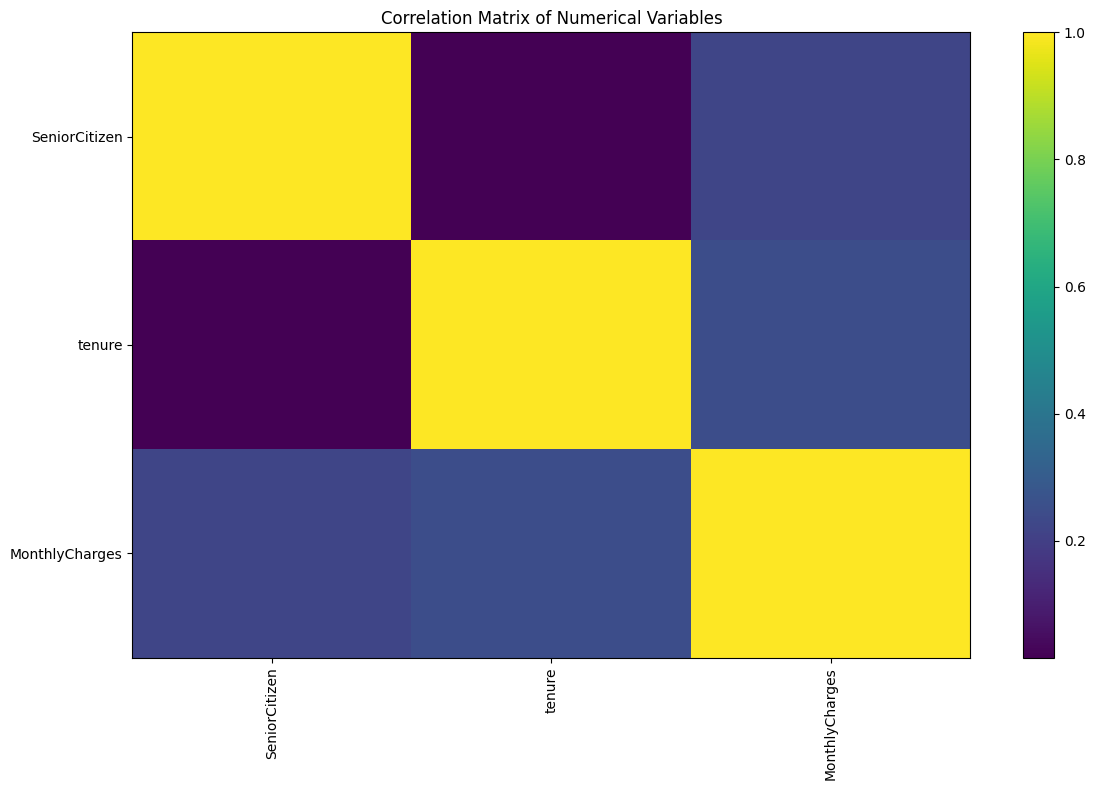

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first five rows
df.head()
# Count employees in each attrition category
print(df["Churn"].value_counts())

# Calculate percentage of each category
print(df["Churn"].value_counts(normalize=True) * 100)

# Plot attrition distribution
df["Churn"].value_counts().plot(kind="bar")

plt.title("Employee Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

overtime_attrition = pd.crosstab(
    df["Contract"], # Changed 'OverTime' to 'Contract'
    df["Churn"],
    normalize="index"
) * 100

print(overtime_attrition)

# Plot the result
overtime_attrition.plot(kind="bar")

plt.title("Churn Rate by Contract Type") # Updated title for 'Contract'
plt.xlabel("Contract Type") # Updated xlabel for 'Contract'
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Calculate churn percentage by internet service
satisfaction_attrition = pd.crosstab(
    df["InternetService"], # Changed 'JobSatisfaction' to 'InternetService'
    df["Churn"],
    normalize="index"
) * 100

print(satisfaction_attrition)

# Plot
satisfaction_attrition.plot(kind="bar")

plt.title("Churn Rate by Internet Service Type") # Updated title for 'InternetService'
plt.xlabel("Internet Service Type") # Updated xlabel for 'InternetService'
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Compare average monthly charges for customers
# who stayed and customers who left
income_by_attrition = df.groupby("Churn")["MonthlyCharges"].mean() # Changed MonthlyIncome to MonthlyCharges

print(income_by_attrition)

# Plot
income_by_attrition.plot(kind="bar")

plt.title("Average Monthly Charges by Churn") # Updated title for MonthlyCharges
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges") # Updated ylabel for MonthlyCharges
plt.xticks(rotation=0)
plt.show()

# Compare average tenure by attrition
age_by_attrition = df.groupby("Churn")["tenure"].mean() # Changed Age to tenure

print(age_by_attrition)

# Plot
age_by_attrition.plot(kind="bar")

plt.title("Average Tenure by Churn") # Updated title for tenure
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)") # Updated ylabel for tenure
plt.xticks(rotation=0)
plt.show()
# Calculate churn rate for each payment method
jobrole_attrition = pd.crosstab(
    df["PaymentMethod"], # Changed JobRole to PaymentMethod
    df["Churn"],
    normalize="index"
) * 100

print(jobrole_attrition)

# Plot
jobrole_attrition["Yes"].sort_values().plot(kind="barh")

plt.title("Customer Churn Rate by Payment Method") # Updated title for PaymentMethod
plt.xlabel("Churn Percentage")
plt.ylabel("Payment Method") # Updated ylabel for PaymentMethod
plt.show()
# Calculate churn percentage by senior citizen status
worklife_attrition = pd.crosstab(
    df["SeniorCitizen"], # Changed WorkLifeBalance to SeniorCitizen
    df["Churn"],
    normalize="index"
) * 100

print(worklife_attrition)

# Plot
worklife_attrition.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status") # Updated title for SeniorCitizen
plt.xlabel("Senior Citizen (0: No, 1: Yes)") # Updated xlabel for SeniorCitizen
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Select numerical columns
numerical_df = df.select_dtypes(include="number")

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Display correlation matrix
print(correlation_matrix)


# Plot correlation matrix
plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()